In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


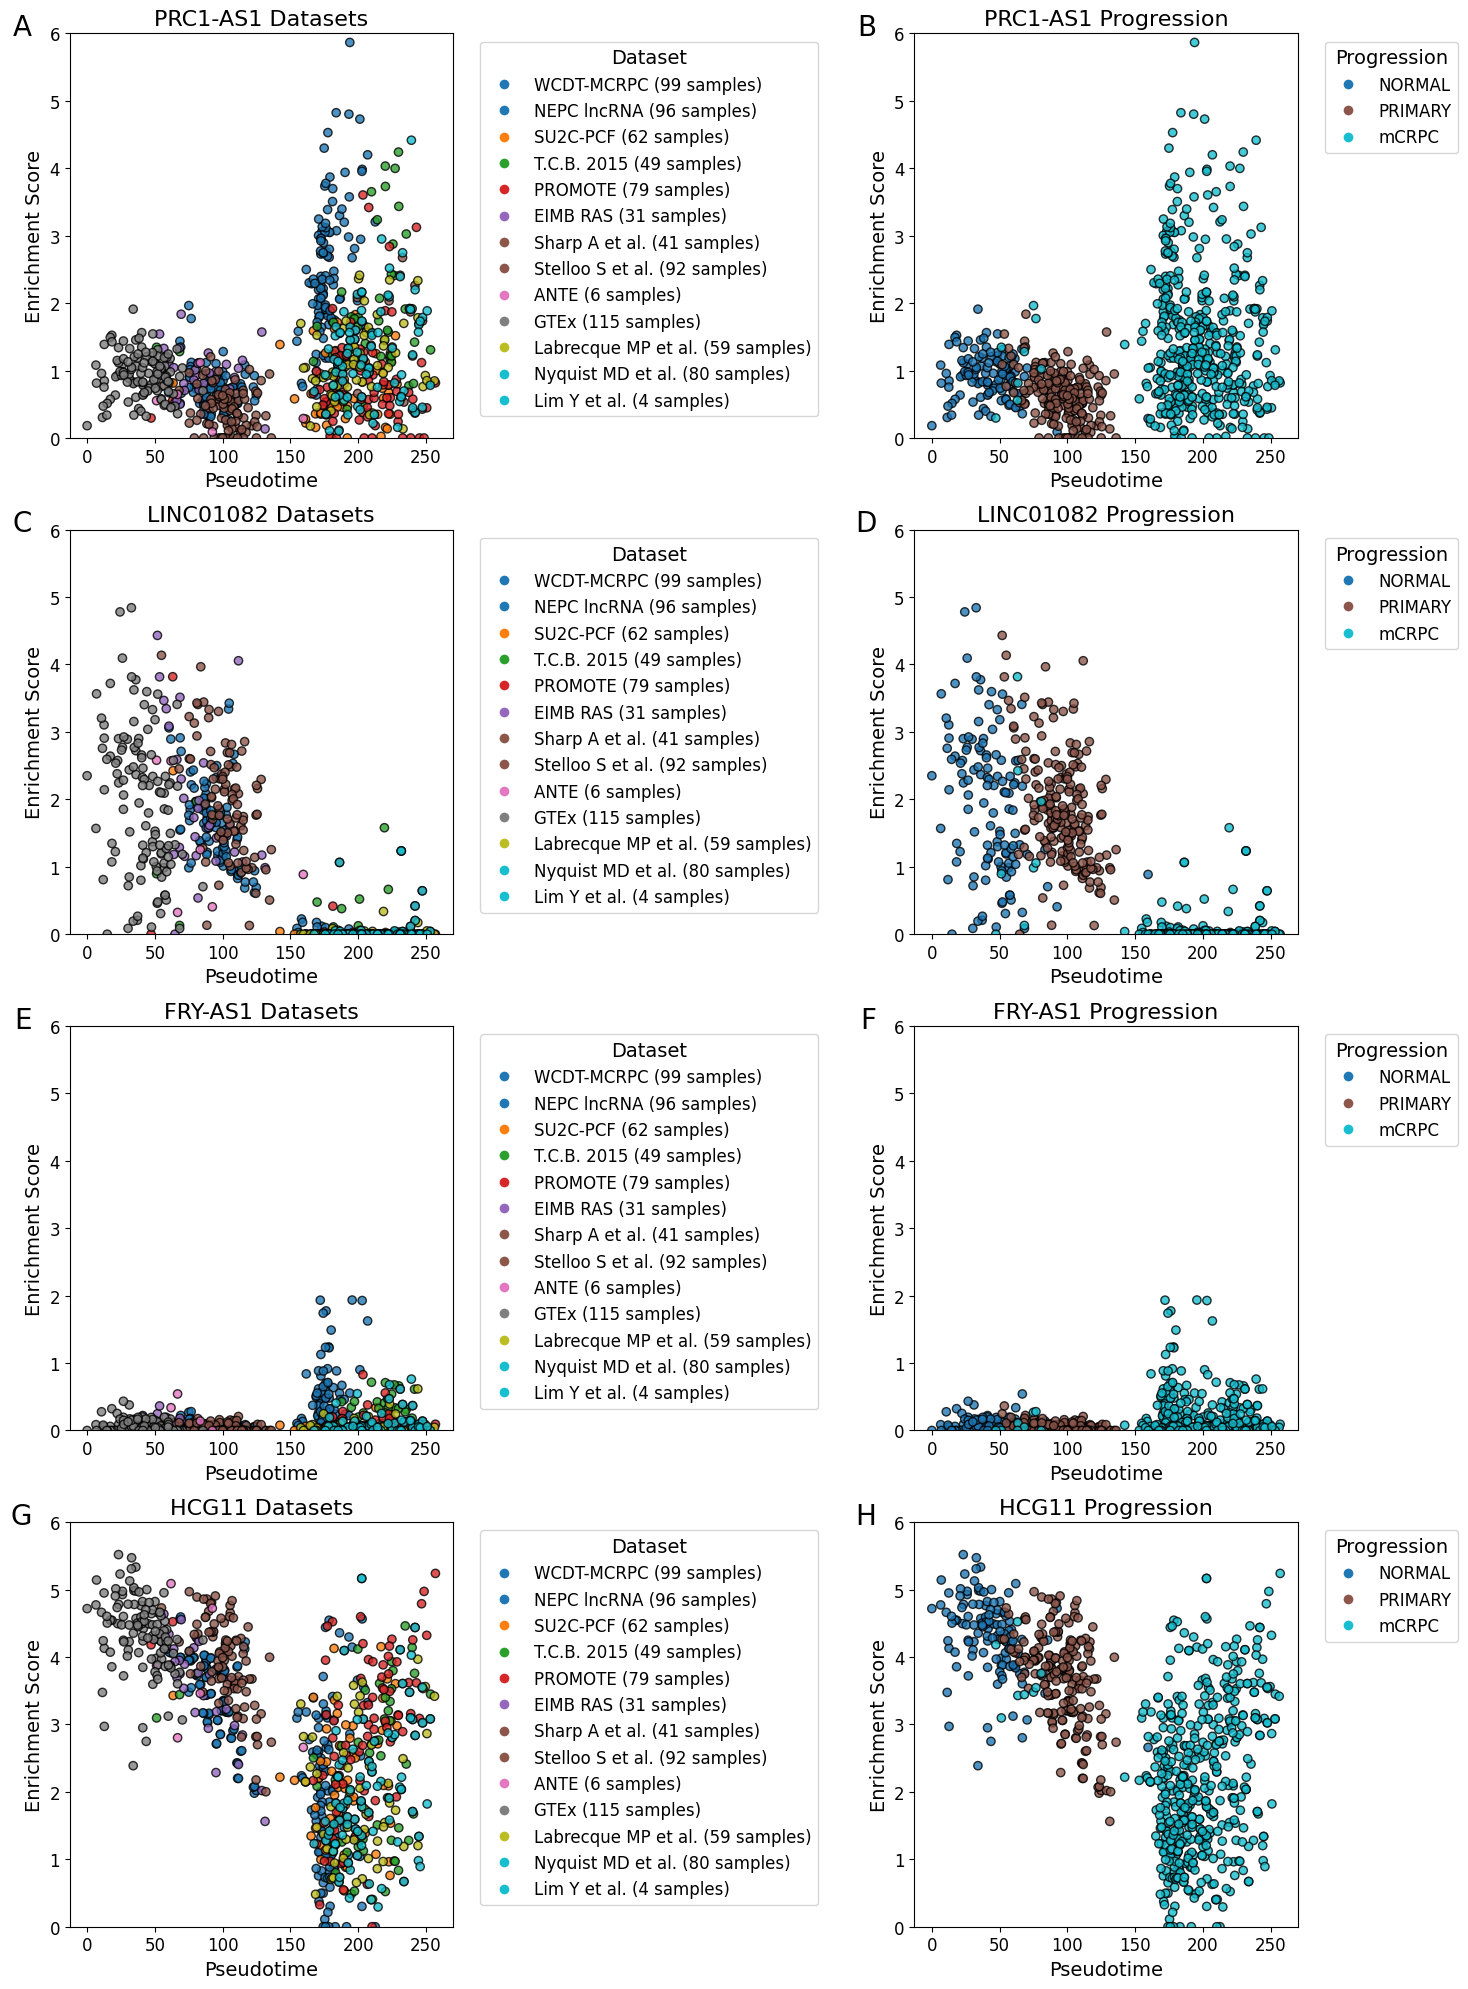

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Define genes and file paths
genes = ["PRC1-AS1", "LINC01082", "FRY-AS1", "HCG11"]
base_path = "../../../data/Prostate_Atlas/"

# Create figure with 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(15, 20))  # 4x2 layout

# Letters for labeling subplots
letters = [chr(i) for i in range(65, 65 + 8)]  # A-H

for i, gene in enumerate(genes):
    # Load bulk dataset
    df_bulk = pd.read_csv(f"{base_path}{gene}_bulk_plot_dataset.csv", sep=",")
    df_bulk.columns = df_bulk.columns.str.strip()
    
    # Bulk scatter plot (left column)
    scatter_bulk = axes[i, 0].scatter(
        x=df_bulk["x"],
        y=df_bulk["y"],
        c=pd.factorize(df_bulk["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    legend_labels_bulk = df_bulk["name"].unique()
    handles_bulk = [
        plt.Line2D([], [], marker="o", color="w", markerfacecolor=scatter_bulk.cmap(scatter_bulk.norm(j)),
                   markersize=8, label=label)
        for j, label in enumerate(legend_labels_bulk)
    ]
    axes[i, 0].legend(handles=handles_bulk, title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)
    axes[i, 0].set_xlabel("Pseudotime", fontsize=14)
    axes[i, 0].set_ylabel("Enrichment Score", fontsize=14)
    axes[i, 0].set_title(f"{gene} Datasets", fontsize=16)
    axes[i, 0].tick_params(axis='both', which='major', labelsize=12)
    axes[i, 0].set_ylim(0, 6)
    axes[i, 0].text(-0.1, 1.05, letters[i*2], transform=axes[i, 0].transAxes,
                    fontsize=20, va='top', ha='right')

    # Load progression dataset
    df_prog = pd.read_csv(f"{base_path}{gene}_bulk_plot_progression.csv", sep=",")
    df_prog.columns = df_prog.columns.str.strip()
    
    # Progression scatter plot (right column)
    scatter_prog = axes[i, 1].scatter(
        x=df_prog["x"],
        y=df_prog["y"],
        c=pd.factorize(df_prog["name"])[0],
        cmap="tab10",
        alpha=0.8,
        edgecolor="k"
    )
    legend_labels_prog = df_prog["name"].unique()
    handles_prog = [
        plt.Line2D([], [], marker="o", color="w", markerfacecolor=scatter_prog.cmap(scatter_prog.norm(j)),
                   markersize=8, label=label)
        for j, label in enumerate(legend_labels_prog)
    ]
    axes[i, 1].legend(handles=handles_prog, title="Progression", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)
    axes[i, 1].set_xlabel("Pseudotime", fontsize=14)
    axes[i, 1].set_ylabel("Enrichment Score", fontsize=14)
    axes[i, 1].set_title(f"{gene} Progression", fontsize=16)
    axes[i, 1].tick_params(axis='both', which='major', labelsize=12)
    axes[i, 1].set_ylim(0, 6)
    axes[i, 1].text(-0.1, 1.05, letters[i*2 + 1], transform=axes[i, 1].transAxes,
                    fontsize=20, va='top', ha='right')

plt.tight_layout()
fig.savefig("../../figures/Prostate_Atlas.png", dpi=300, bbox_inches='tight')
plt.show()
